Use this notebook to check if all the modules are working independently

In [334]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import importlib

# Plot Styling
plt.style.use('dark_background')
plt.rcParams.update({
    'font.family':'serif', 'mathtext.fontset':'dejavuserif',
    'axes.grid':True, 'grid.linestyle': ':', 'grid.alpha': 0.5,
    'xtick.direction':'in', 'xtick.minor.visible': True, 'xtick.top':True,
    'ytick.direction':'in', 'ytick.minor.visible': True, 'ytick.right':True,
    'figure.figsize': [9, 6], 'axes.titlesize':30, 'legend.fontsize': 15, 'legend.title_fontsize': 20,
    'axes.labelsize':25, 'xtick.labelsize':15, 'ytick.labelsize':15
})

# Cosmology Functions

In [335]:
import Models.HaloModels as HaloModels
importlib.reload(HaloModels)

ast = HaloModels.astropy_model()
pyc = HaloModels.pyccl_model({'MassDef':'200c', 'MassFunc':'Tinker08', 'HaloBias':'Tinker10', 'Concentration':'Diemer15'})
col = HaloModels.colossus_model({'MassDef':'200c', 'MassFunc':'tinker08', 'HaloBias':'tinker10', 'Concentration':'diemer15', 'PlinMod':'camb'})

## Basic redshift functions

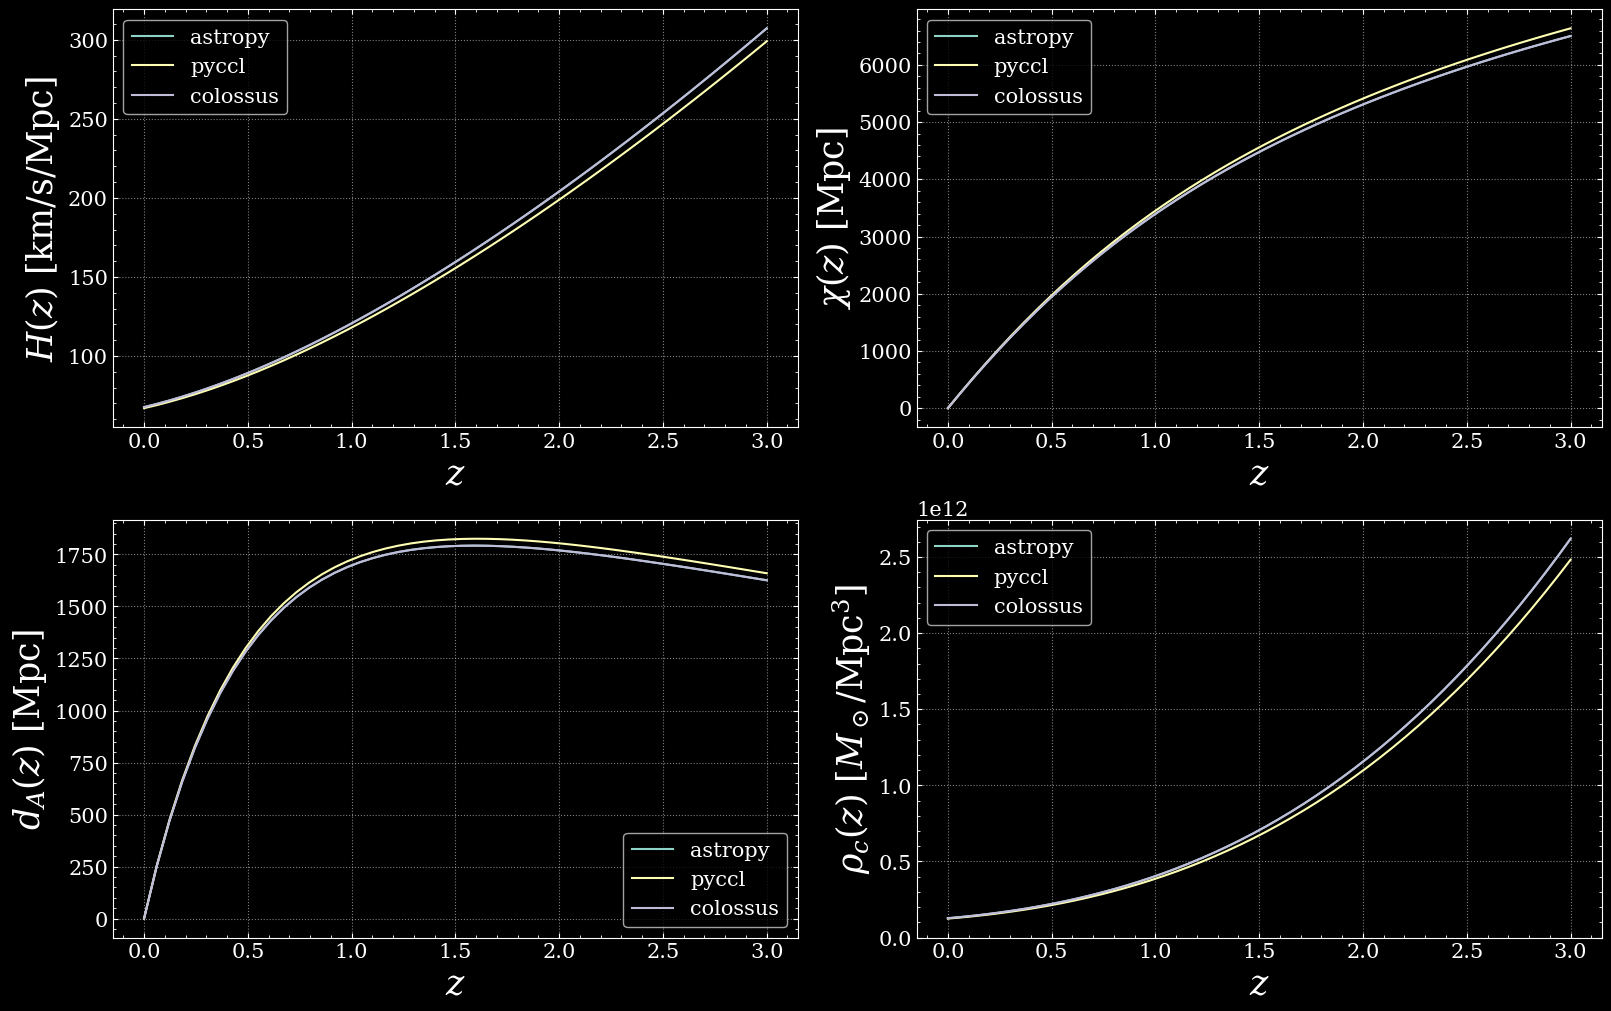

In [336]:
zs = np.linspace(0, 3)

fig, axs = plt.subplots(2, 2, figsize=(16, 10), layout='constrained')
axs=axs.flatten()

axs[0].plot(zs, ast.H(zs), label=f'astropy')
axs[1].plot(zs, ast.chi(zs), label=f'astropy')
axs[2].plot(zs, ast.dA(zs), label=f'astropy')
axs[3].plot(zs, ast.rhoc(zs), label=f'astropy')

axs[0].plot(zs, pyc.H(zs), label=f'pyccl')
axs[1].plot(zs, pyc.chi(zs), label=f'pyccl')
axs[2].plot(zs, pyc.dA(zs), label=f'pyccl')
axs[3].plot(zs, pyc.rhoc(zs), label=f'pyccl')

axs[0].plot(zs, col.H(zs), label=f'colossus')
axs[1].plot(zs, col.chi(zs), label=f'colossus')
axs[2].plot(zs, col.dA(zs), label=f'colossus')
axs[3].plot(zs, col.rhoc(zs), label=f'colossus')

axs[0].set(ylabel=r'$H(z) \ [\text{km/s/Mpc}]$', xlabel=r'$z$'); axs[0].legend()
axs[1].set(ylabel=r'$\chi(z) \ [\text{Mpc}]$', xlabel=r'$z$'); axs[1].legend()
axs[2].set(ylabel=r'$d_A(z) \ [\text{Mpc}]$', xlabel=r'$z$'); axs[2].legend()
axs[3].set(ylabel=r'$\rho_c(z) \ [M_\odot/\text{Mpc}^3]$', xlabel=r'$z$'); axs[3].legend()

plt.show()

## More complicated redshift and mass fucntions

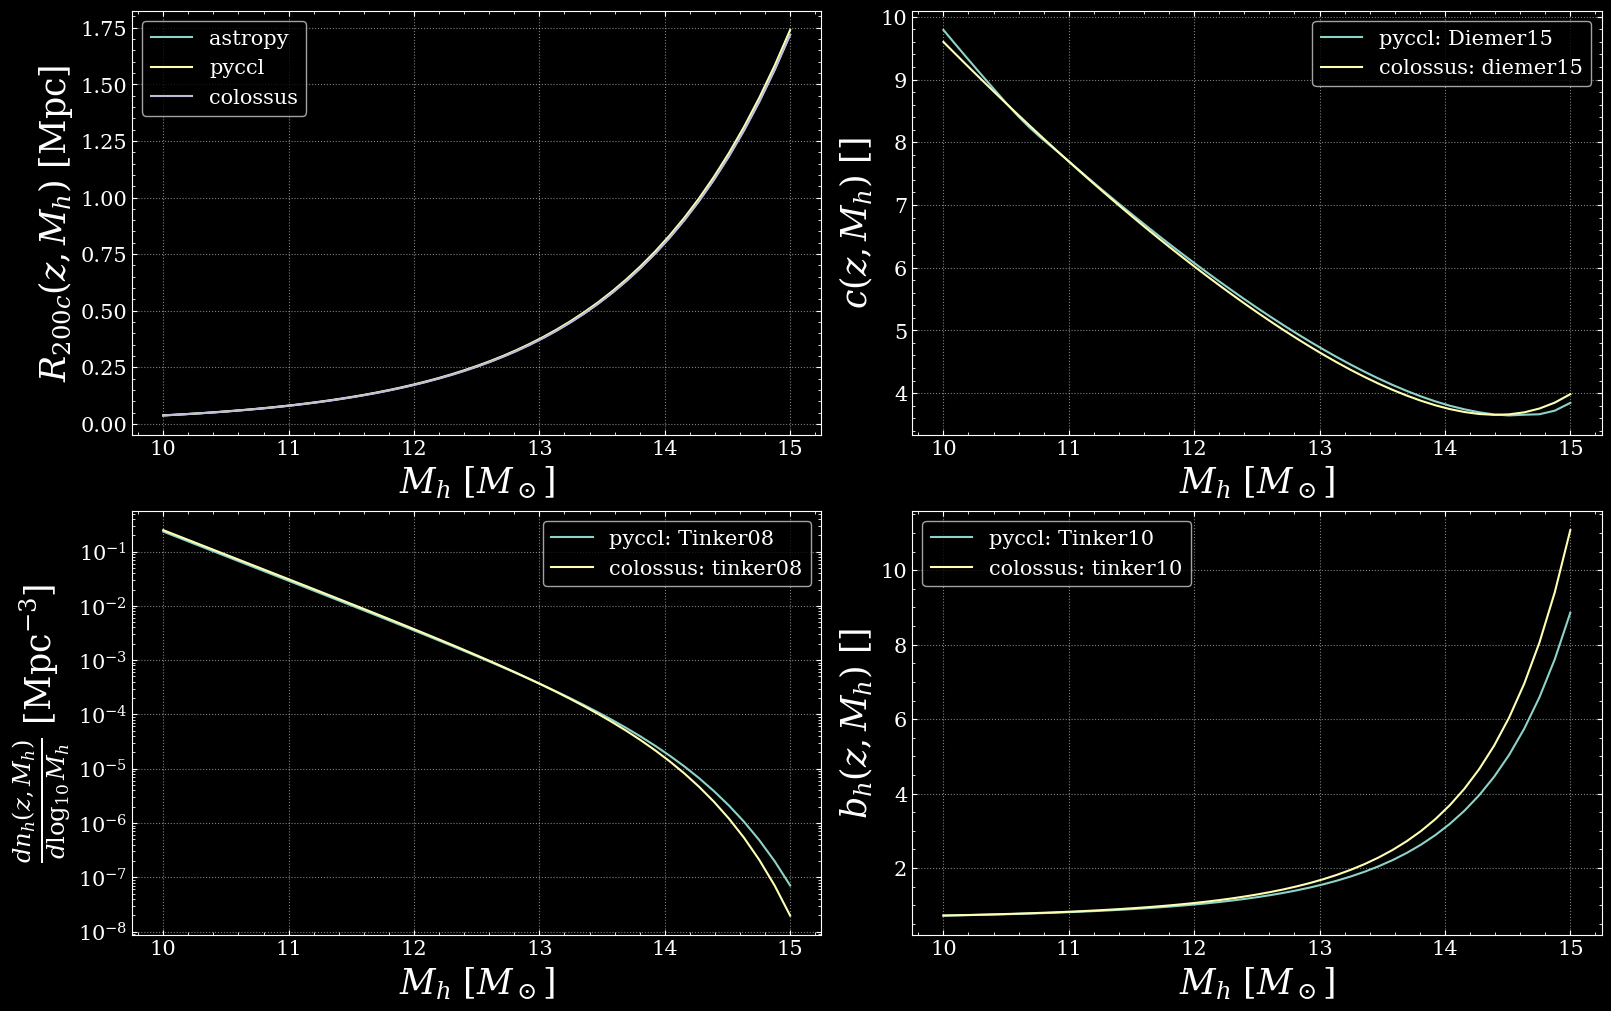

In [337]:
z, logmhalos = 0.55, np.geomspace(10, 15)

fig, axs = plt.subplots(2, 2, figsize=(16, 10), layout='constrained')
axs = axs.flatten()

axs[0].plot(logmhalos, ast.r200c(z, logmhalos), label=f'astropy')

axs[0].plot(logmhalos, pyc.r200c(z, logmhalos), label=f'pyccl')
axs[1].plot(logmhalos, pyc.c(z, logmhalos), label=f'pyccl: {pyc.Concentration}')
axs[2].plot(logmhalos, pyc.dndlogm(z, logmhalos), label=f'pyccl: {pyc.MassFunc}')
axs[3].plot(logmhalos, pyc.bh(z, logmhalos), label=f'pyccl: {pyc.HaloBias}')

axs[0].plot(logmhalos, col.r200c(z, logmhalos), label=f'colossus')
axs[1].plot(logmhalos, col.c(z, logmhalos), label=f'colossus: {col.Concentration}')
axs[2].plot(logmhalos, col.dndlogm(z, logmhalos), label=f'colossus: {col.MassFunc}')
axs[3].plot(logmhalos, col.bh(z, logmhalos), label=f'colossus: {col.HaloBias}')

axs[0].set(ylabel=r'$R_{200c}(z, M_h) \ [\text{Mpc}]$', xlabel=r'$M_h \ [M_\odot]$'); axs[0].legend()
axs[1].set(ylabel=r'$c(z, M_h) \ []$', xlabel=r'$M_h \ [M_\odot]$'); axs[1].legend()
axs[2].set(ylabel=r'$\frac{dn_h(z, M_h)}{d\log_{10} M_h}$ [Mpc$^{-3}$]', xlabel=r'$M_h \ [M_\odot]$', yscale='log'); axs[2].legend()
axs[3].set(ylabel=r'$b_h(z, M_h) \ []$', xlabel=r'$M_h \ [M_\odot]$'); axs[3].legend()

plt.show()

## Power spectra

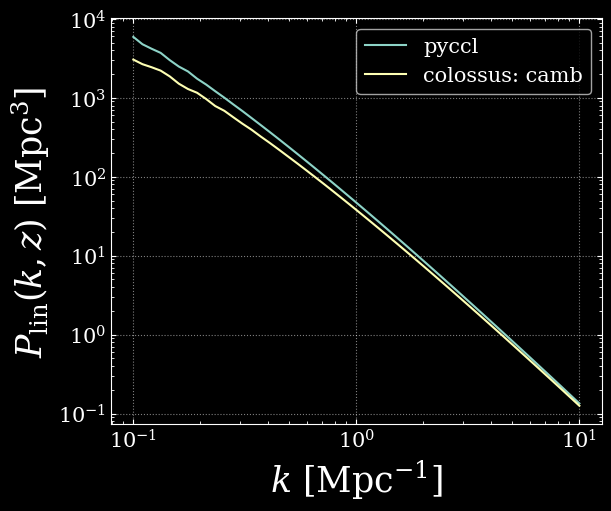

In [338]:
z, ks = 0.55, np.logspace(-1, 1, 50)

fig, ax = plt.subplots(1, 1, figsize=(6, 5), layout='constrained')

ax.loglog(ks, pyc.Plin(ks, z), label=f'pyccl')
ax.loglog(ks, col.Plin(ks, z), label=f'colossus: {col.PlinMod}')

ax.set(ylabel=r'$P_\text{lin}(k, z) \ [\text{Mpc}^3]$', xlabel=r'$k \ [\text{Mpc}^{-1}]$'); ax.legend()
plt.show()

# Halo Profiles

Density and Pressure profiles are the crux of the forward model, containing the baryonic astrophysics we'd want to examine.

$P_\text{th}(x, z, m_h) = P_{200, \text{crit}} (m, z) \ P_\text{th, 0} (z, m_h)\Big[\frac{x}{x_c(z, m_h)}\Big]^\gamma\bigg[1+\Big[\frac{x}{x_c(z, m_h)}\Big]^{\alpha(z, m_h)} \bigg]^{\beta(z, m_h)}$

The two-halo requires quite a bit of set up, calculated through the same method of calculating cross-spectra.

In [345]:
import Models.Studies as Studies
import Models.HaloModels as HaloModels
importlib.reload(Studies); importlib.reload(HaloModels)

cpars = Studies.Amodeo2021.info
hmod = HaloModels.pyccl_model({'MassDef':'200c', 'MassFunc':'Tinker08', 'HaloBias':'Tinker10', 'Concentration':'Diemer15'}, **cpars)

import Models.Profiles as Profiles
importlib.reload(Profiles)
Battaglia11 = Profiles.Battaglia2011({},rhoc=hmod.rhoc, r200c=hmod.r200c, **cpars)
Battaglia18 = Profiles.Battaglia2018({'model':'AGN'}, rhoc=hmod.rhoc, r200c=hmod.r200c, **cpars)
Amodeo = Profiles.Amodeo2021({'model':'GNFW'},rhoc=hmod.rhoc, r200c=hmod.r200c, dndlogm=hmod.dndlogm, bh=hmod.bh, Plin=hmod.Plin)

AttributeError: 'Battaglia2011' object has no attribute 'setdim'

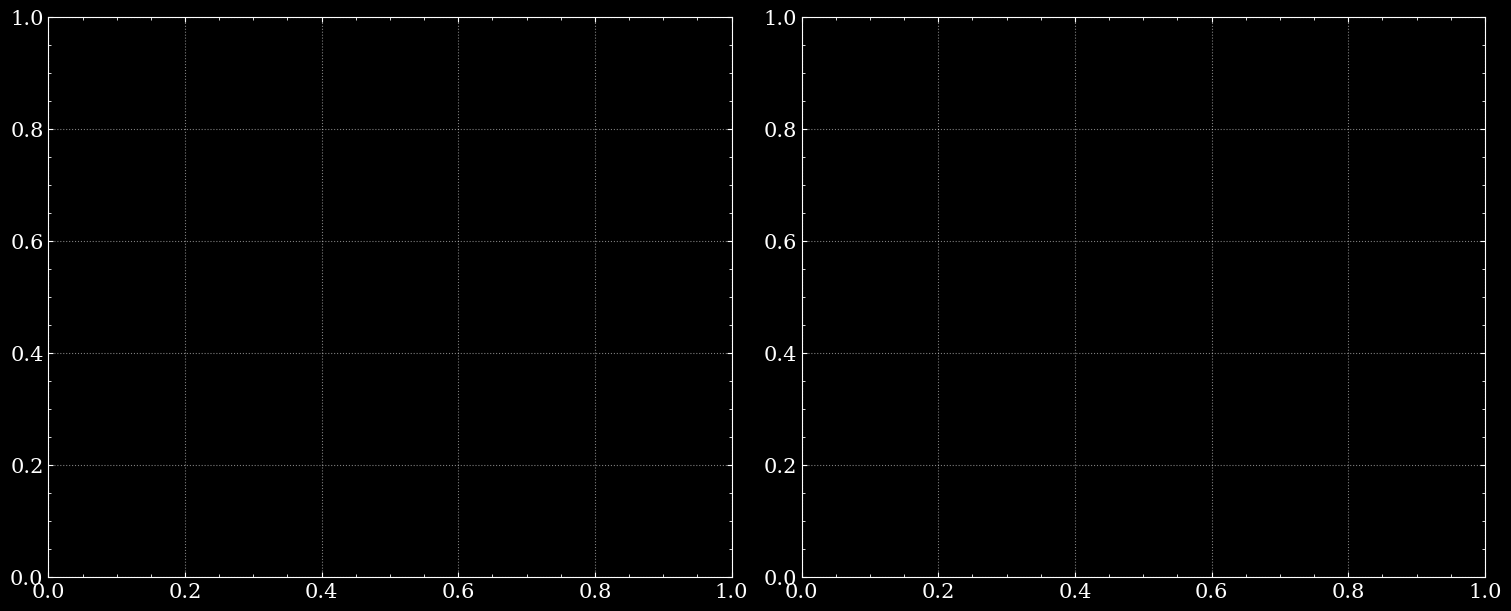

In [346]:
rs, z, logmhalo = np.geomspace(1e-3, 1e6, 100), Amodeo.z_med, np.round(np.log10(Amodeo.mhalo_mean), 1)

fig, axs = plt.subplots(1, 2, figsize=(15, 6), layout='constrained')

axs[1].loglog(rs, Battaglia11.Pth1h(rs, z, logmhalo, units='cgs')()[:, 0, 0], ls='--', label='Battaglia 2012', c='coral')
axs[0].loglog(rs, Battaglia18.rho1h(rs, z, logmhalo, units='cgs')()[:, 0, 0], ls='--', c='coral', label='Battaglia 2012')

axs[1].loglog(rs, Amodeo.Pth(rs, z, logmhalo, units='cgs')()[:, 0, 0], label='Amodeo 2021', c='skyblue')
axs[1].loglog(rs, Amodeo.Pth1h(rs, z, logmhalo, units='cgs')()[:, 0, 0], ls='--', c='skyblue')
axs[1].loglog(rs, Amodeo.Pth2h(rs, z, logmhalo, units='cgs')()[:, 0, 0], c='skyblue', ls=':')

axs[0].loglog(rs, Amodeo.rho(rs, z, logmhalo, units='cgs')()[:, 0, 0], label='Amodeo 2021', c='skyblue')
axs[0].loglog(rs, Amodeo.rho1h(rs, z, logmhalo, units='cgs')()[:, 0, 0], c='skyblue', ls='--')
axs[0].loglog(rs, Amodeo.rho2h(rs, z, logmhalo, units='cgs')()[:, 0, 0], c='skyblue', ls=':')

fig.suptitle(f'$z$={z}, log$M_h$={logmhalo}', fontsize=30)
axs[1].set(ylabel=r'$P_\text{th}(r, z, M_h)$ [dyne cm$^{-2}$]', xlabel=r'$r$ [Mpc]', ylim=(1e-16, 5e-12), xlim=(1e-1, 1e1)); axs[0].legend()
axs[0].set(ylabel=r'$\rho_\text{gas}(r, z, M_h)$ [g cm$^{-3}]$', xlabel=r'$r$ [Mpc]', ylim=(1e-31, 5e-27), xlim=(1e-1, 1e1)); axs[1].legend()

plt.show()

# Halo Occupancy Distributions

If you're calculating sample-averaged profiles through the galaxy-$y$ cross-spectra, you need an HOD which describes the average number of central/satellite galaxies as a function of halo mass.

In [343]:
import Models.HODs as HODs
importlib.reload(HODs)

DESI = HODs.DESI_1P({'zbin':'LRG1'})
BOSSDR12 = HODs.SDSS_BOSS_DR12({'mbin':'M1'})
unWISE = HODs.unWISE({'sample':'Red'})
KV450xG = HODs.KV450xGAMA({'sample':'MSr'})
BOSSDR11 = HODs.SDSS_BOSS_DR11({'mbin':'M2'})

## Number

$\bar{N}_c(M_h) = \frac{f_\text{ic}}{2} \bigg[ 1+ \text{erf} \bigg( \frac{\log_{10} M_h - \log_{10} M_\text{min}}{\sigma} \bigg) \bigg]$
, $\quad$
$\bar{N}_s(M_h) = \bigg[ \frac{M_h-M_0}{M_1} \bigg]^{\alpha} 
\bar{N}_c(M_h)$

AttributeError: 'DESI_1P' object has no attribute 'p0'

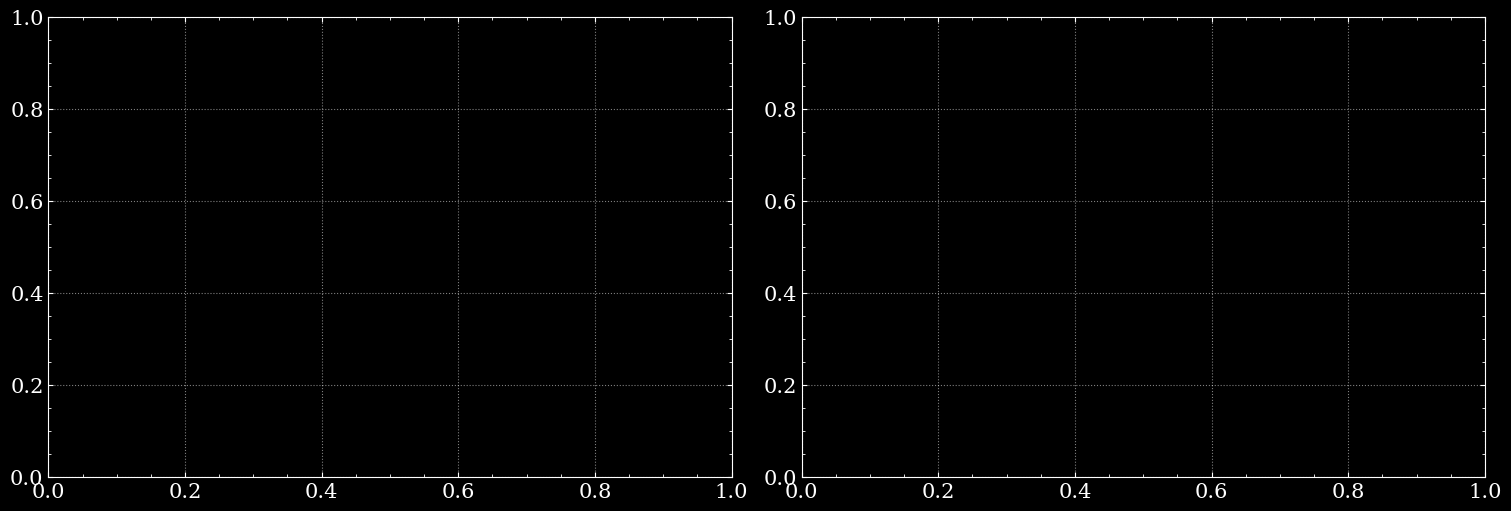

In [344]:
logMs = np.geomspace(10, 15)

fig, axs = plt.subplots(1, 2, figsize=(15, 5), layout='constrained', sharex=True)
axs = axs.flatten()

axs[0].plot(logMs, DESI.Nc(logMs)(), label='DESI 1P')
axs[1].plot(logMs, DESI.Ns(logMs)(), label='DESI 1P')

axs[0].plot(logMs, BOSSDR12.Nc(logMs)(), label='BOSSDR12')
axs[1].plot(logMs, BOSSDR12.Ns(logMs)(), label='BOSSDR12')

axs[0].plot(logMs, unWISE.Nc(logMs)(), label='unWISE')
axs[1].plot(logMs, unWISE.Ns(logMs)(), label='unWISE')

axs[0].plot(logMs, KV450xG.Nc(logMs)(), label='KV450xGAMA')
axs[1].plot(logMs, KV450xG.Ns(logMs)(), label='KV450xGAMA')

axs[0].plot(logMs, BOSSDR11.Nc(logMs)(), label='BOSS DR11')
axs[1].plot(logMs, BOSSDR11.Ns(logMs)(), label='BOSS DR11')

axs[0].set(ylabel=r'$\overline{N_c} (M_h) \ []$', xlabel=r'log$M_h \ [M_\odot]$', xlim=(11, 15)); axs[0].legend()
axs[1].set(ylabel=r'$\overline{N_s} (M_h) \ []$', xlabel=r'log$M_h \ [M_\odot]$', yscale='log', ylim=(1e-4, 1e3)); axs[1].legend()


plt.show()

## Density

In [252]:
import Models.Studies as Studies
import Models.HaloModels as HaloModels
importlib.reload(Studies); importlib.reload(HaloModels)

cpars = Studies.Kusiak2022.info
hmod = HaloModels.pyccl_model({'MassDef':'200c', 'MassFunc':'Tinker08', 'HaloBias':'Tinker10', 'Concentration':'Bhattacharya13'}, **cpars)

import Models.HODs as HODs
importlib.reload(HODs)

Yuan = HODs.Yuan2023({'zbin':'LRG1'}, r200m=hmod.r200c, c200m=hmod.c, **cpars)
Kou = HODs.Kou2023({'mbin':'M1'}, r200m=hmod.r200c, c200m=hmod.c, **cpars)
Kusiak = HODs.Kusiak2022({'sample':'Red'}, rhoc=hmod.rhoc, r200c=hmod.r200c, c200c=hmod.c, **cpars)
Linke = HODs.Linke2022({'sample':'MSr'}, rhoc=hmod.rhoc, r200m=hmod.r200c, c200m=hmod.c, **cpars)
More = HODs.More2015({'mbin':'2'}, r200m=hmod.r200c, c200m=hmod.c, **cpars)

In [256]:
np.trapz(Linke.ns_r(rs, zs, logMs)()*4*np.pi*rs[:, None, None]**2, rs, axis=0),\
np.trapz(Kou.ns_r(rs, zs, logMs)()*4*np.pi*rs[:, None, None]**2, rs, axis=0), \
np.trapz(Kusiak.ns_r(rs, zs, logMs)()*4*np.pi*rs[:, None, None]**2, rs, axis=0)

(<Quantity [[1.88418767, 1.86363218, 1.8420018 , 1.81943587, 1.79604863],
            [2.19534395, 2.17456272, 2.15276606, 2.13012507, 2.10678419],
            [2.56478971, 2.54480333, 2.52390055, 2.50230427, 2.4802109 ]] 1 / Mpc3>,
 <Quantity [[1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1.]]>,
 array([[0.06107048, 0.03513745, 0.01999504, 0.01125132, 0.00625966],
        [0.06408342, 0.03690202, 0.02101777, 0.01183833, 0.00659298],
        [0.06730605, 0.03879125, 0.02211484, 0.01246876, 0.00695181]]))

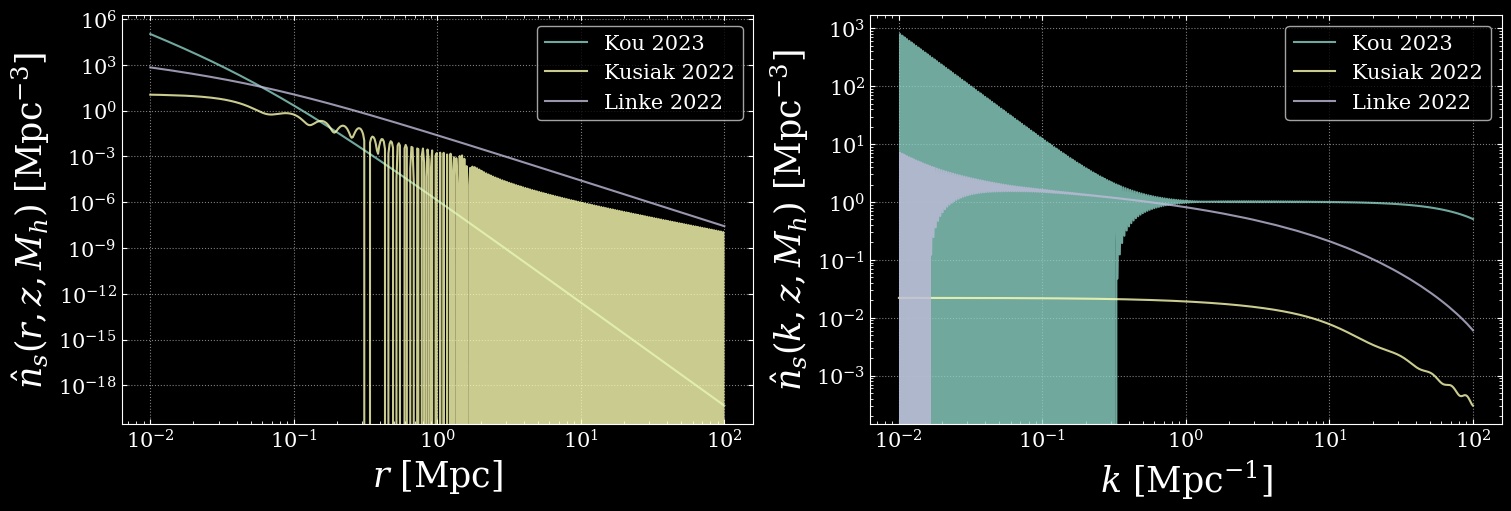

In [255]:
ks, z, logM = np.geomspace(1e-2, 1e2, 500), 0.55, 12.5
rs = np.geomspace(1e-2, 1e2, 500)

fig, axs = plt.subplots(1, 2, figsize=(15, 5), layout='constrained', sharex=True)
axs = axs.flatten()

axs[0].plot(rs, Kou.ns_r(rs, z, logM)()[:, 0, 0], alpha=0.8,label='Kou 2023')
axs[1].plot(ks, Kou.ns(ks, z, logM)()[:, 0, 0], alpha=0.8, label='Kou 2023')

axs[0].plot(rs, Kusiak.ns_r(rs, z, logM)()[:, 0, 0],alpha=0.8, label='Kusiak 2022')
axs[1].plot(ks, Kusiak.ns(ks, z, logM)()[:, 0, 0],alpha=0.8, label='Kusiak 2022')

axs[0].plot(rs, Linke.ns_r(rs, z, logM)()[:, 0, 0], alpha=0.8, label='Linke 2022')
axs[1].plot(ks, Linke.ns(ks, z, logM)()[:, 0, 0], alpha=0.8,label='Linke 2022')


axs[0].set(ylabel=r'$\hat{n}_s (r, z, M_h) \ [\text{Mpc}^{-3}]$', xlabel=r'$r \ [\text{Mpc}]$', xscale='log', yscale='log'); axs[0].legend()
axs[1].set(ylabel=r'$\hat{n}_s (k, z, M_h) \ [\text{Mpc}^{-3}]$', xlabel=r'$k \ [\text{Mpc}^{-1}]$', yscale='log'); axs[1].legend()

plt.show()

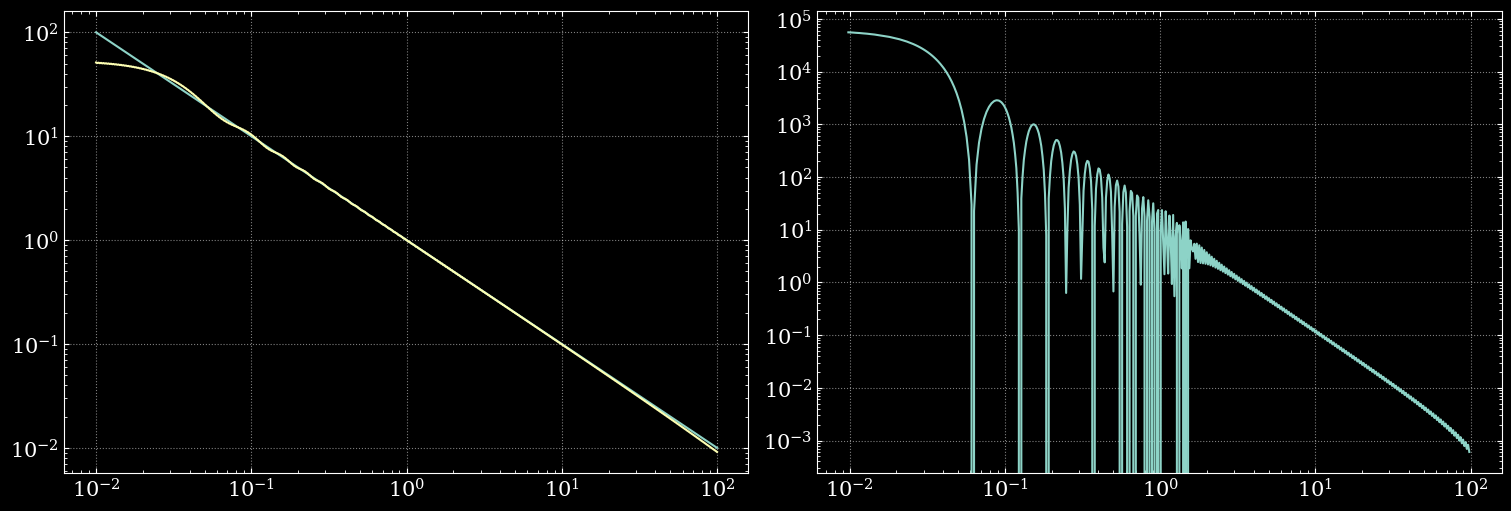

In [56]:
import Models.FFTs as FFTs

fig, axs = plt.subplots(1, 2, figsize=(15, 5), layout='constrained', sharex=True)

fft = FFTs.mcfit_package(ks=ks)
axs[0].loglog(ks, 1/ks)
axs[1].loglog(fft.rs, fft.FFT1D(1/ks))
axs[0].loglog(ks, fft.IFFT1D(fft.FFT1D(1/ks)))

# Stellar-Halo Mass Relations

If you're using a Stellar Mass Function (SMF) in a weighted average to calculate sample-average halo profiles or to inform the bounds of the mass range of your sample, you need to use a SHMR to convert the solar mass units of the SMF to halo mass units that most profile models use. 

In [22]:
import Models.SHMRs as SHMRs
importlib.reload(SHMRs)

# Load in the model
Xu = SHMRs.Xu2023({'sample':'CMASS', 'form':'BP13'})
Gao = SHMRs.Gao2023({'sample': 'ELG'})
Kravstov = SHMRs.Kravstov2018({'mdef':'mvir', 'scatter':'S'})

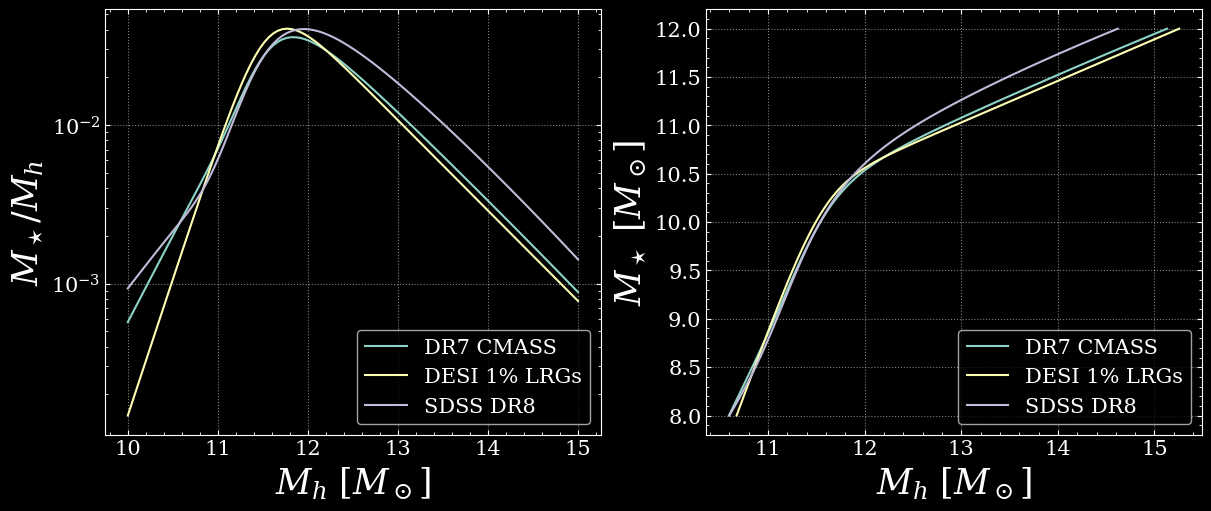

In [23]:
logMhs = np.linspace(10, 15, 100)
logMss = np.linspace(8, 12, 100)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')

axs[0].plot(logmhalo, 10**Xu.HSMR(logMhs)()/10**logMhs, label='DR7 CMASS')
axs[1].plot(Xu.SHMR(logMss)(), logMss, label='DR7 CMASS')

axs[0].plot(logmhalo, 10**Gao.HSMR(logMhs)()/10**logMhs, label='DESI 1% LRGs')
axs[1].plot(Gao.SHMR(logMss)(), logMss, label='DESI 1% LRGs')

axs[0].plot(logmhalo, 10**Kravstov.HSMR(logMhs)()/10**logMhs, label='SDSS DR8')
axs[1].plot(Kravstov.SHMR(logMss)(), logMss, label='SDSS DR8')

axs[0].set(xlabel=r'$M_h \ [M_\odot]$', ylabel=r'$M_\star / M_h$', yscale='log'); axs[0].legend()
axs[1].set(xlabel=r'$M_h \ [M_\odot]$', ylabel=r'$M_\star \ [M_\odot]$'); axs[1].legend()

plt.show()

# Dust Profiles

necessary for some tSZ measurements to account for contamination.

In [48]:
import Models.Dust as Dust
importlib.reload(Dust)
importlib.reload(Studies)

AmodeoDust = Dust.Amodeo2021({'fitto':'ACTH'})

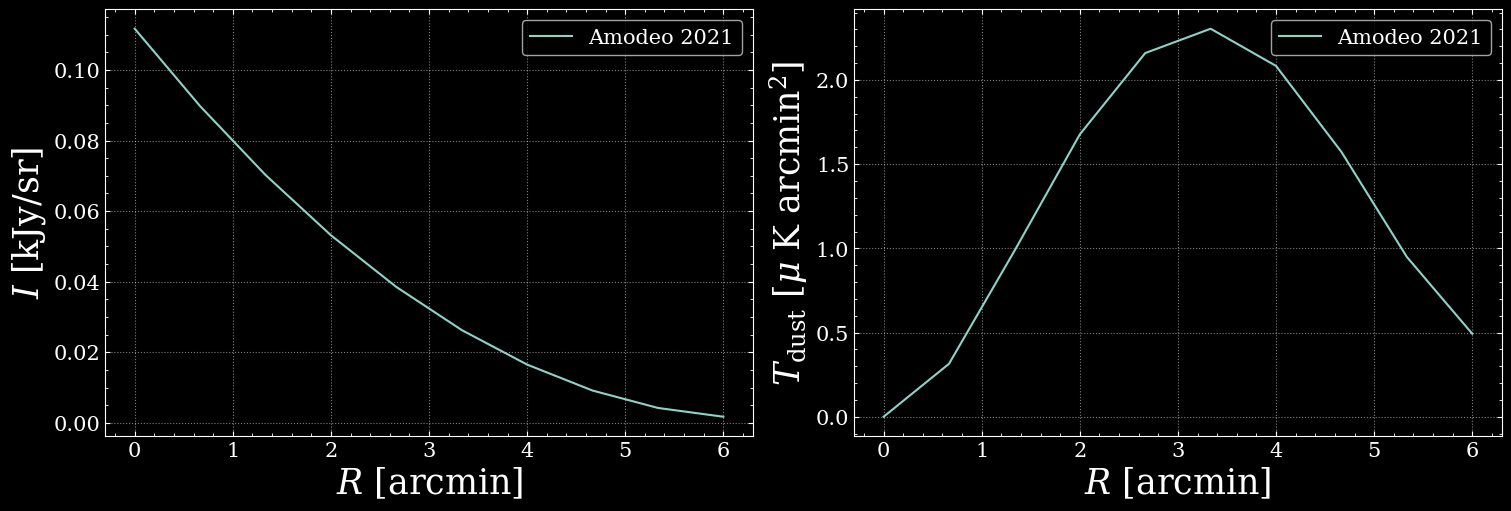

In [49]:
Rs = np.linspace(0, 6, 10)
freq = 150

fig, axs = plt.subplots(1, 2, figsize=(15, 5), layout='constrained')

axs[0].plot(Rs, AmodeoDust.dustpoly(Rs, freq)(), label='Amodeo 2021')
axs[1].plot(Rs, AmodeoDust.dust_uKarcmin(Rs, freq)(), label='Amodeo 2021')

axs[0].set(xlabel=r'$R$ [arcmin]', ylabel=r'$I$ [kJy/sr]'); axs[0].legend()
axs[1].set(xlabel=r'$R$ [arcmin]', ylabel=r'$T_\text{dust}$ [$\mu$ K arcmin$^2$]'); axs[1].legend()

plt.show()